# Parallelization

To compare Python’s multiprocessing with C’s threading, we use the computation of Mandelbrot set pixels as a benchmark problem.
This problem can be formulated as follows: for each point $c\in\mathbb{C}$ on a grid, we determine whether the sequence 
$$
    z_{n+1}=z_n^2+c
$$ 
remains bounded. Each pixel is then assigned a value 
$$
    \mu_\text{pixel} = k + 1 - \frac{\log(\log |z_k|)}{\log(2)}
$$ 
where $k$ is the smallest index for which $|z_k|>2$. With this procedure, we can generate figures like

<p align="center">
    <img src="../results/example.png" width="500"/>
</p>

Since evaluating $\mu_\text{pixel}$ is computationally expensive, it is well suited as a benchmark problem.

## Strategies

### C-Threading with `pthread`
*What are threads?* 

A thread is a lightweight unit of execution within a process. Multiple threads share the same memory and can run in parallel.

<p align="center">
    <img src="../results/threading.svg" width="700"/>
</p>

> **Pros:**
> - each thread run in parallel on multiple CPU-cores
> - efficient for CPU-intensive tasks

> **Cons:**
> - more complex to implement
> - requires synchronization (shared memory must be protected from concurrent access)

### Python-Multiprocessing with `multiprocessing`
*What are GIL (Global Interpreter Lock)?*

A mechanism in CPython that allows only **one thread** to execute Python bytecode (process) at a time, preventing true parallel 
execution of threads.

*How can parallelization be achieved in Python?*

Using separate processes with their own memory, which bypasses the GIL-mechanism.

<p align="center">
    <img src="../results/multiprocessesing.svg" width="700"/>
</p>

> **Pros:**
> - processes can run in parallel on multiple CPU cores
> - suitable for CPU-intensive tasks (similar scaling to C in many cases)
> - avoids GIL limitations

> **Cons:**
> - processes have their own memory (data exchange is more complex than in C threads)
> - object-oriented designs become more difficult, since each process operates on its own copy rather than a shared object

#### Work around for object-oriented designs

One way to preserve an object-oriented design when using multiprocessing is to rely on `multiprocessing.shared_memory`. 
This allows class instances to work with shared data instead of process-local copies. For example, the following class stores a 
NumPy array in shared memory so that methods executed in different processes can access the same underlying data.

In [ ]:
from multiprocessing import Process
from multiprocessing.shared_memory import SharedMemory
from numpy import ndarray

class MyClass:
    def __init__(self, data: ndarray):
        # create shared memory block
        self.shm = SharedMemory(create=True, size=data.nbytes)

        self.data = ndarray(
            shape=data.shape,   # shape must match
            dtype=data.dtype,   # dtype must match
            buffer=self.shm.buf # link self.data to shared memory
        )

        self.data[:] = data[:]  # copy entries into shared memory

    def compute(self):
        # create processes
        p1 = Process(
            target=MyClass._worker,
            args=(self.shm.name, self.data.shape, self.data.dtype, 1)
        )
        p2 = Process(
            target=MyClass._worker,
            args=(self.shm.name, self.data.shape, self.data.dtype, 2)
        )

        # start processes
        p1.start()
        p2.start()

        # join processes
        p1.join()
        p2.join()

    @staticmethod
    def _worker(name, shape, dtype, case):
        # connect to existing shared memory in separate process
        shm = SharedMemory(name=name)

        # create array view onto shared memory
        data = ndarray(
            shape=shape,
            dtype=dtype,
            buffer=shm.buf
        )

        if case == 1:
            pass  # do something with one part of the array
        elif case == 2:
            pass  # do something with another part of the array

        shm.close() # close access in this separate process

    def cleanup(self):
        self.shm.close()   # close access in this process
        self.shm.unlink()  # release the shared memory block

*Key notes for `MyClass._worker`:*
- `MyClass._worker` has to be a static method or a non-member function (especially on Windows).
- within `MyClass._worker`, an array view has to be created that points to the shared memory block to be modified
- at the end of `MyClass._worker`, access to the shared memory block has to be closed 

Usage:

---
~~~py
if __name__ == "__main__":
    obj = MyClass(data) # creating instance with shared memory block
    obj.compute() # call parallelized method
    obj.cleanup() # clean up (close access and release shared memory block)
~~~
---

*Key notes for usage:*
- Parallel execution works reliably only when protected by the
    ~~~py
    if __name__ == "__main__":
        pass
    ~~~
    guard (especially on Windows).
- after the computation has finished, the shared memory must be cleaned up, i.e., close access and release the shared memory block

## Benchmark cases
1) threading (entirely C) for 1-10 threads
1) multiprocessing (entirely Python) for 1-10 processes
3) threading (Python with `ctypes`-api) for 1-10 threads

In [2]:
import matplotlib.pyplot as plt
from utils import run_c, run_py, run_cpy

warmup = 3
repeats = 10
subprocesses = list(range(1, 11))

### C (pthread)

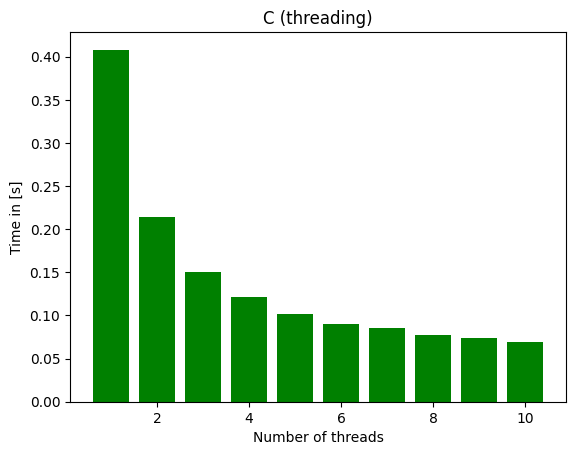

In [3]:
c_label = "C (threading)"
c_times = []
for i in subprocesses:
    c_times.append(sum(run_c(i, warmup, repeats)) / repeats)

plt.bar(subprocesses, c_times, color="green")
plt.title(c_label)
plt.xlabel("Number of threads")
plt.ylabel("Time in [s]")
plt.show()

### Python (multiprocessing)

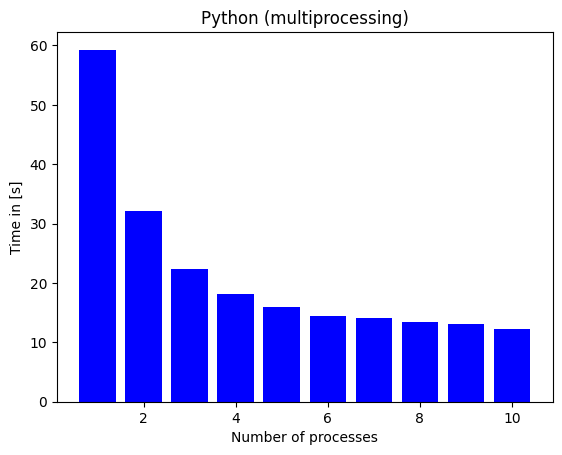

In [4]:
py_label = "Python (multiprocessing)"
py_times = []
for i in subprocesses:
    py_times.append(sum(run_py(i, warmup, repeats)) / repeats)

plt.bar(subprocesses, py_times, color="blue")
plt.title(py_label)
plt.xlabel("Number of processes")
plt.ylabel("Time in [s]")
plt.show()

### Python (`ctypes`-api)

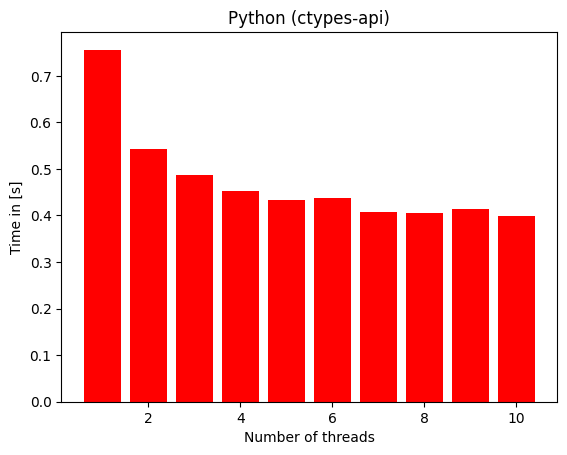

In [5]:
cpy_label = "Python (ctypes-api)"
cpy_times = [] 
for i in subprocesses:
    cpy_times.append(sum(run_cpy(i, warmup, repeats)) / repeats)

plt.bar(subprocesses, cpy_times, color="red")
plt.title(cpy_label)
plt.xlabel("Number of threads")
plt.ylabel("Time in [s]")
plt.show()

### Comparison

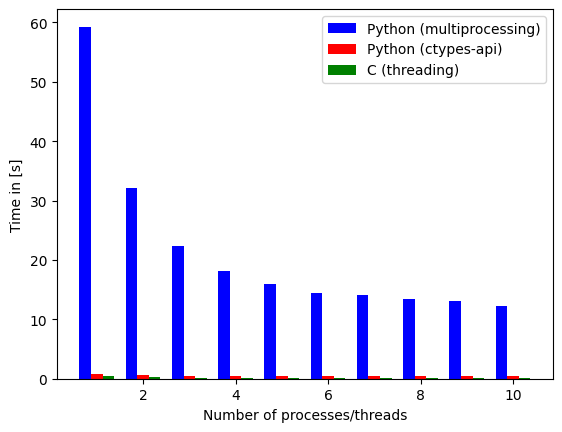

In [6]:
from numpy import array
width = 0.25
x = array(subprocesses)
plt.bar(x - width, py_times, width, label=py_label, color="blue")
plt.bar(x, cpy_times, width, label=cpy_label, color="red")
plt.bar(x + width, c_times, width, label=c_label, color="green")
plt.legend()
plt.xlabel("Number of processes/threads")
plt.ylabel("Time in [s]")
plt.show()